INTRA-CLASS STABILITY MINING (KNEES BENDING ONLY)
Train Subjects: [1, 2, 3, 4, 6, 7, 8, 9, 10]
Test Subject: [5]
Loading mHealth logs from: /content/drive/MyDrive/Colab Notebooks/HAR_data/MHEALTHDATASET
Processing mHealth_subject1.log...
  -> Subject 1: Loaded 3379 samples.
Processing mHealth_subject2.log...
  -> Subject 2: Loaded 3430 samples.
Processing mHealth_subject3.log...
  -> Subject 3: Loaded 3175 samples.
Processing mHealth_subject4.log...
  -> Subject 4: Loaded 3123 samples.
Processing mHealth_subject5.log...
  -> Subject 5: Loaded 2714 samples.
Processing mHealth_subject6.log...
  -> Subject 6: Loaded 2304 samples.
Processing mHealth_subject7.log...
  -> Subject 7: Loaded 2816 samples.
Processing mHealth_subject8.log...
  -> Subject 8: Loaded 2560 samples.
Processing mHealth_subject9.log...
  -> Subject 9: Loaded 2969 samples.
Processing mHealth_subject10.log...
  -> Subject 10: Loaded 2867 samples.
Data Loaded. Train Samples: 26623, Test Samples: 2714

[Sanity Check] Runni

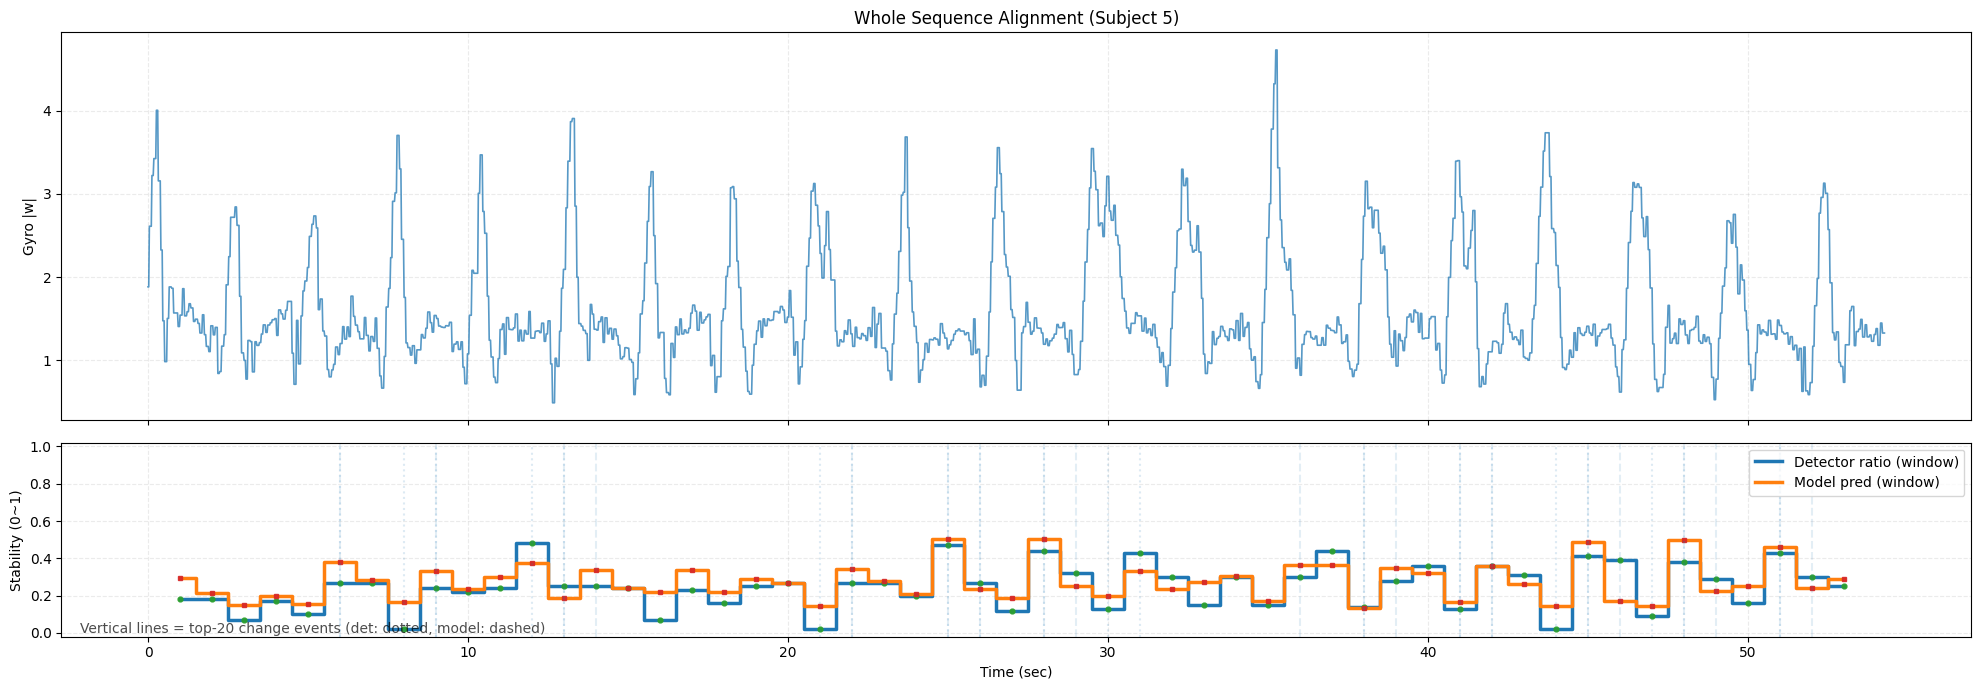

In [1]:
import os
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt

# ==========================================
# 0. Configuration
# ==========================================
CONFIG = {
    'window_size': 100,
    'stride': 50,
    'batch_size': 64,
    'lr': 1e-3,
    'epochs': 50,
    'feature_dim': 64,
    'lambda_recon': 1.0,
    'lambda_orient': 1.0,        # Orientation continuity loss
    'lambda_inertial': 0.3,      # Inertial invariance loss
    'lambda_contrast': 0.5,      # Steady vs Transition contrast
    'fs': 50,
    'seed': 42,

    # [수정 2] Test Subject = 5, Train = Others
    'train_subjects': [1, 2, 3, 4, 6, 7, 8, 9, 10],
    'test_subjects': [5],

    # Stability Mining Parameters
    'scale_factor': 10.0,        # Sharp Peak를 위한 Scaling
    'stability_threshold': 0.5,  # 이 점수 이상이어야 '안정'으로 간주
}

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def set_seed(seed):
    torch.manual_seed(seed)
    np.random.seed(seed)

set_seed(CONFIG['seed'])

# ==========================================
# 1. Inverted Inertial Detector (Stability Mining)
# ==========================================
class InvertedInertialDetector:
    """
    동작 내 전이(Intra-class Transition)를 위한 안정성 탐지기
    Output Score: 1.0 (Perfectly Stable) -> 0.0 (Moving)
    """
    def __init__(self, fs=50, scale_factor=50.0, stability_threshold=0.6):
        self.fs = fs
        self.scale_factor = scale_factor
        self.stability_threshold = stability_threshold

    def detect(self, acc, gyro):
        """
        acc: (N, 3), gyro: (N, 3)
        Returns: stability_score (N,)
        """
        # 1. 중력 가속도 분산 (Gravity Variance)
        w_size = int(0.25 * self.fs)

        acc_df = pd.DataFrame(acc, columns=['x', 'y', 'z'])
        var_s = acc_df.rolling(window=w_size, center=True, min_periods=1).var().sum(axis=1).values
        var_s = np.nan_to_num(var_s)
        norm_var = np.clip(var_s / 5.0, 0, 1)  # Normalization

        # 2. 회전량 (Angular Change)
        gyro_mag = np.linalg.norm(gyro, axis=1)
        gyro_series = pd.Series(gyro_mag)
        smooth_gyro = gyro_series.rolling(window=w_size, center=True, min_periods=1).mean().values
        norm_gyro = np.clip(smooth_gyro / 300.0, 0, 1)  # Normalization

        # 3. Energy Function (낮을수록 안정)
        total_energy = norm_var + norm_gyro

        # 4. Inverted Score Calculation
        stability_score = np.exp(-self.scale_factor * total_energy)

        return stability_score

# ==========================================
# 2. Orientation-Aware Dataset
# ==========================================
class OrientationAwareDataset(Dataset):
    def __init__(self, sequences, detector, config):
        self.sequences = sequences
        self.detector = detector
        self.config = config
        self.stability_labels = []

        print(f"Computing stability-based labels for {len(sequences)} windows...")
        for seq in sequences:
            acc = seq[:, :3]
            gyro = seq[:, 3:6]

            # Detect Stability Score
            score = detector.detect(acc, gyro)

            # Window-level label: 1.0에 가까울수록 Stable
            stability_ratio = np.mean(score > detector.stability_threshold)
            self.stability_labels.append(stability_ratio)

        self.stability_labels = np.array(self.stability_labels)
        print(f"Dataset created. Stable windows: {np.sum(self.stability_labels > 0.5)}/{len(sequences)}")

    def __len__(self):
        return len(self.sequences)

    def __getitem__(self, idx):
        seq = self.sequences[idx]
        label_val = self.stability_labels[idx]

        # Convert to torch
        x = torch.tensor(seq, dtype=torch.float32).transpose(0, 1)
        y = torch.tensor(label_val, dtype=torch.float32)

        return x, y

# ==========================================
# 3. Model Architecture
# ==========================================
class OrientationInvariantEncoder(nn.Module):
    def __init__(self, input_ch=6, hidden_dim=128, latent_dim=64, win_size=100):
        super().__init__()

        # Shared feature extractor
        self.feature_extractor = nn.Sequential(
            nn.Conv1d(input_ch, hidden_dim, kernel_size=7, padding=3),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(),
            nn.Conv1d(hidden_dim, hidden_dim, kernel_size=5, padding=2),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(),
        )

        # Steady state encoder
        self.enc_steady = nn.Sequential(
            nn.Conv1d(hidden_dim, hidden_dim, kernel_size=3, padding=1),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(),
            nn.AdaptiveAvgPool1d(1),
            nn.Flatten(),
            nn.Linear(hidden_dim, latent_dim),
            nn.ReLU()
        )

        # Transition/Motion encoder
        self.enc_transition = nn.Sequential(
            nn.Conv1d(hidden_dim, hidden_dim, kernel_size=3, padding=1),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(),
            nn.AdaptiveMaxPool1d(1),
            nn.Flatten(),
            nn.Linear(hidden_dim, latent_dim),
            nn.ReLU()
        )

        # Stability Predictor
        self.orientation_predictor = nn.Sequential(
            nn.Linear(latent_dim, 32),
            nn.ReLU(),
            nn.Linear(32, 1),
            nn.Sigmoid()
        )

        # Decoder
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim * 2, hidden_dim * win_size // 4),
            nn.ReLU(),
            nn.Unflatten(1, (hidden_dim, win_size // 4)),
            nn.ConvTranspose1d(hidden_dim, hidden_dim, kernel_size=4, stride=2, padding=1),
            nn.ReLU(),
            nn.ConvTranspose1d(hidden_dim, input_ch, kernel_size=4, stride=2, padding=1),
        )
        self.win_size = win_size

    def forward(self, x):
        features = self.feature_extractor(x)
        z_steady = self.enc_steady(features)
        z_transition = self.enc_transition(features)

        stability_pred = self.orientation_predictor(z_steady)

        z_combined = torch.cat([z_steady, z_transition], dim=1)
        x_recon = self.decoder(z_combined)

        if x_recon.size(2) != self.win_size:
            x_recon = F.interpolate(x_recon, size=self.win_size, mode='linear', align_corners=False)

        return z_steady, z_transition, stability_pred, x_recon

# ==========================================
# 4. Loss Functions
# ==========================================
def orientation_continuity_loss(z_steady, labels, steady_thr=0.7, var_weight=0.25, var_gamma=0.5):
    device = z_steady.device
    steady_idx = torch.where(labels > steady_thr)[0]

    if steady_idx.numel() < 2:
        return torch.tensor(0.0, device=device)

    z = z_steady[steady_idx]

    # Invariance
    dist = torch.cdist(z, z, p=2)
    n = dist.size(0)
    off_diag = dist[~torch.eye(n, dtype=torch.bool, device=device)]
    loss_invar = off_diag.mean()

    # Variance
    std = z.std(dim=0) + 1e-6
    loss_var = F.relu(var_gamma - std).mean()

    return loss_invar + var_weight * loss_var

def steady_transition_contrast_loss(z_steady, z_transition, labels, steady_thr=0.7, trans_thr=0.3):
    device = z_steady.device
    steady_idx = torch.where(labels > steady_thr)[0]
    trans_idx = torch.where(labels < trans_thr)[0]

    if trans_idx.numel() < 1 or steady_idx.numel() < 1:
        return torch.tensor(0.0, device=device)

    zs_s = F.normalize(z_steady[steady_idx], dim=1)
    zt_t = F.normalize(z_transition[trans_idx], dim=1)

    sim_matrix = torch.mm(zs_s, zt_t.t())
    loss_ortho = sim_matrix.abs().mean()

    return loss_ortho

def inertial_invariance_loss(z_steady, x, eps=1e-6):
    acc = x[:, :3, :]
    g = acc.mean(dim=2)
    g = F.normalize(g, dim=1, eps=eps)

    z = z_steady
    z = z - z.mean(dim=0, keepdim=True)
    z = z / (z.std(dim=0, keepdim=True) + eps)

    g = g - g.mean(dim=0, keepdim=True)
    g = g / (g.std(dim=0, keepdim=True) + eps)

    B = z.size(0)
    C = (z.T @ g) / (B + eps)
    loss = (C ** 2).mean()
    return loss

# ==========================================
# 5. Training Loop (Detailed Logging)
# ==========================================
def train(model, loader, config):
    optimizer = torch.optim.AdamW(model.parameters(), lr=config['lr'], weight_decay=1e-4)
    model.train()

    print("\n[Training Stability Miner - Detailed Logs]")
    print(f"{'Epoch':^6} | {'Total':^8} | {'Recon':^8} | {'Pred':^8} | {'Cont':^8} | {'Inert':^8} | {'Ctrst':^8}")
    print("-" * 75)

    for epoch in range(config['epochs']):
        # Loss Accumulators 초기화
        acc_total = 0
        acc_recon = 0
        acc_pred = 0
        acc_cont = 0
        acc_inertial = 0
        acc_contrast = 0

        for x, labels in loader:
            x = x.to(DEVICE)
            labels = labels.to(DEVICE)

            z_steady, z_transition, pred, x_recon = model(x)

            # 1. Reconstruction Loss
            loss_recon = F.mse_loss(x_recon, x)

            # 2. Prediction Loss (Soft-target BCE: ratio 그대로 사용)
            loss_pred = F.binary_cross_entropy(pred.view(-1), labels)

            # 3. Continuity Loss
            loss_cont = orientation_continuity_loss(z_steady, labels)

            # 4. Inertial Invariance Loss
            loss_inertial = inertial_invariance_loss(z_steady, x)

            # 5. Contrast Loss
            loss_contrast = steady_transition_contrast_loss(z_steady, z_transition, labels)

            # Total Weighted Loss
            loss = (config['lambda_recon'] * loss_recon +
                    config['lambda_orient'] * (loss_pred + loss_cont) +
                    config['lambda_inertial'] * loss_inertial +
                    config['lambda_contrast'] * loss_contrast)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            # Accumulate values for logging (item()으로 값만 추출)
            acc_total += loss.item()
            acc_recon += loss_recon.item()
            acc_pred += loss_pred.item()
            acc_cont += loss_cont.item()
            acc_inertial += loss_inertial.item()
            acc_contrast += loss_contrast.item()

        # Epoch 단위 평균 계산 및 출력
        n = len(loader)
        print(f"{epoch+1:03d}/{config['epochs']} | "
              f"{acc_total/n:.4f} | "
              f"{acc_recon/n:.4f} | "
              f"{acc_pred/n:.4f} | "
              f"{acc_cont/n:.4f} | "
              f"{acc_inertial/n:.4f} | "
              f"{acc_contrast/n:.4f}")

    return model

# ==========================================
# 6. Evaluation (No Counting) & Visualization (SHOW only)
# ==========================================
def _pearson_corr(a, b):
    a = np.asarray(a, dtype=np.float64)
    b = np.asarray(b, dtype=np.float64)
    if len(a) < 2 or np.std(a) < 1e-12 or np.std(b) < 1e-12:
        return 0.0
    return float(np.corrcoef(a, b)[0, 1])

def _spearman_corr(a, b):
    a = np.asarray(a, dtype=np.float64)
    b = np.asarray(b, dtype=np.float64)
    if len(a) < 2:
        return 0.0
    # rank transform (ties are rare here; simple argsort-based rank)
    ra = np.argsort(np.argsort(a))
    rb = np.argsort(np.argsort(b))
    return _pearson_corr(ra, rb)

def _topk_event_times(score_series, time_series, k=20):
    """
    score_series: (T,) window-level series in [0,1]
    time_series : (T,) seconds
    Event strength = |diff(score)|
    Return: event_times (<=k,)
    """
    s = np.asarray(score_series, dtype=np.float64)
    t = np.asarray(time_series, dtype=np.float64)
    if len(s) < 3:
        return np.array([], dtype=np.float64)

    ds = np.abs(np.diff(s))  # length T-1
    if ds.size == 0:
        return np.array([], dtype=np.float64)

    k = int(min(k, ds.size))
    # indices in diff domain; event time is at t[i+1] (after change)
    idx = np.argpartition(-ds, kth=k-1)[:k]
    # sort by strength desc
    idx = idx[np.argsort(-ds[idx])]
    return t[idx + 1]

def _match_events(det_times, mdl_times, tol_sec=0.3):
    """
    Greedy matching within tolerance.
    Returns: precision, recall, f1, mean_abs_timing_error_sec
    """
    det_times = list(np.asarray(det_times, dtype=np.float64))
    mdl_times = list(np.asarray(mdl_times, dtype=np.float64))
    if len(det_times) == 0 and len(mdl_times) == 0:
        return 1.0, 1.0, 1.0, 0.0
    if len(det_times) == 0:
        return 0.0, 0.0, 0.0, 0.0
    if len(mdl_times) == 0:
        return 0.0, 0.0, 0.0, 0.0

    det_used = [False] * len(det_times)
    matched_err = []

    for mt in mdl_times:
        best_j = -1
        best_dt = 1e18
        for j, dt in enumerate(det_times):
            if det_used[j]:
                continue
            d = abs(dt - mt)
            if d <= tol_sec and d < best_dt:
                best_dt = d
                best_j = j
        if best_j >= 0:
            det_used[best_j] = True
            matched_err.append(best_dt)

    tp = len(matched_err)
    fp = len(mdl_times) - tp
    fn = len(det_times) - tp

    prec = tp / (tp + fp + 1e-12)
    rec  = tp / (tp + fn + 1e-12)
    f1   = 2 * prec * rec / (prec + rec + 1e-12)
    mean_err = float(np.mean(matched_err)) if matched_err else 0.0
    return float(prec), float(rec), float(f1), mean_err

def visualize_alignment_show(full_data, det_win_ratio, mdl_win_pred, win_center_sec, subject_id,
                             show_events=True, K=20):
    """
    저장 없이 show만.
    2-panel:
      (Top)  gyro magnitude
      (Bottom) detector window-ratio vs model window-pred (0~1)
    + optional: top-K change events를 세로선으로 표시(가시성 ↑)
    """
    gyro_mag = np.linalg.norm(full_data[:, 3:6], axis=1)
    t_full = np.arange(len(gyro_mag), dtype=np.float64) / CONFIG['fs']

    det_win_ratio = np.asarray(det_win_ratio, dtype=np.float64)
    mdl_win_pred  = np.asarray(mdl_win_pred, dtype=np.float64)
    win_center_sec = np.asarray(win_center_sec, dtype=np.float64)

    # ---------- figure ----------
    fig, axes = plt.subplots(2, 1, figsize=(20, 7), sharex=True,
                             gridspec_kw={"height_ratios": [2, 1]})
    ax_g = axes[0]
    ax_s = axes[1]

    # ---------- (Top) Gyro ----------
    ax_g.plot(t_full, gyro_mag, linewidth=1.2, alpha=0.75)
    ax_g.set_ylabel("Gyro |w|")
    ax_g.set_title(f"Whole Sequence Alignment (Subject {subject_id})")
    ax_g.grid(True, linestyle="--", alpha=0.25)

    # ---------- (Bottom) Stability ----------
    # step curves
    ax_s.step(win_center_sec, det_win_ratio, where="mid", linewidth=2.5, label="Detector ratio (window)")
    ax_s.step(win_center_sec, mdl_win_pred,  where="mid", linewidth=2.5, label="Model pred (window)")

    # markers (윈도우 포인트가 또렷하게 보이게)
    ax_s.plot(win_center_sec, det_win_ratio, marker="o", linestyle="None", markersize=3.5, alpha=0.9)
    ax_s.plot(win_center_sec, mdl_win_pred,  marker="s", linestyle="None", markersize=3.5, alpha=0.9)

    ax_s.set_ylim(-0.02, 1.02)
    ax_s.set_ylabel("Stability (0~1)")
    ax_s.set_xlabel("Time (sec)")
    ax_s.grid(True, linestyle="--", alpha=0.25)
    ax_s.legend(loc="upper right", frameon=True)

    # ---------- optional: change events (top-K) ----------
    if show_events and len(win_center_sec) >= 3:
        det_evt = _topk_event_times(det_win_ratio, win_center_sec, k=K)
        mdl_evt = _topk_event_times(mdl_win_pred,  win_center_sec, k=K)

        # Detector events: dotted
        for tt in det_evt:
            ax_s.axvline(tt, linestyle=":", alpha=0.15)
        # Model events: dashed
        for tt in mdl_evt:
            ax_s.axvline(tt, linestyle="--", alpha=0.12)

        # 간단한 안내 텍스트(너무 방해되면 지워도 됨)
        ax_s.text(0.01, 0.02, f"Vertical lines = top-{K} change events (det: dotted, model: dashed)",
                  transform=ax_s.transAxes, fontsize=10, alpha=0.7)

    plt.tight_layout()
    plt.show()


def evaluate_alignment_performance(model, df_test, feature_cols, config):
    model.eval()
    detector = InvertedInertialDetector(fs=config['fs'],
                                        scale_factor=config['scale_factor'],
                                        stability_threshold=config['stability_threshold'])

    test_subjects_str = ",".join(map(str, config['test_subjects']))
    print(f"\n[Evaluating Alignment (No Counting) on Test Subject(s) {test_subjects_str} - Whole Sequence]")

    for sub in config['test_subjects']:
        print(f"Processing Subject {sub}...")
        sub_data = df_test[df_test['subject_id'] == sub][feature_cols].values
        if len(sub_data) == 0:
            continue

        # Normalization (전체 데이터 기준)
        mean = np.mean(sub_data, axis=0)
        std = np.std(sub_data, axis=0) + 1e-6
        norm_data = (sub_data - mean) / std

        acc = norm_data[:, :3]
        gyro = norm_data[:, 3:6]
        det_score = detector.detect(acc, gyro)
        det_bin = (det_score > detector.stability_threshold).astype(np.float32)

        # ---------------------------------------------------------
        # Window-level detector ratio series (label과 동일 정의)
        # ---------------------------------------------------------
        det_win_ratio = []
        win_centers = []
        for w in range(0, len(norm_data) - config['window_size'] + 1, config['stride']):
            seg = det_bin[w: w + config['window_size']]
            det_win_ratio.append(float(np.mean(seg)))
            win_centers.append((w + 0.5 * config['window_size']) / config['fs'])
        det_win_ratio = np.asarray(det_win_ratio, dtype=np.float32)
        win_center_sec = np.asarray(win_centers, dtype=np.float32)

        # ---------------------------------------------------------
        # Window-level model prediction series
        # ---------------------------------------------------------
        mdl_win_pred = []
        for w in range(0, len(norm_data) - config['window_size'] + 1, config['stride']):
            win_data = norm_data[w: w + config['window_size']]
            x_tensor = torch.tensor(win_data, dtype=torch.float32).transpose(0, 1).unsqueeze(0).to(DEVICE)
            with torch.no_grad():
                _, _, pred, _ = model(x_tensor)
            mdl_win_pred.append(float(pred.item()))
        mdl_win_pred = np.asarray(mdl_win_pred, dtype=np.float32)

        # ---------------------------------------------------------
        # Quant: correlation / error (threshold-free)
        # ---------------------------------------------------------
        pear = _pearson_corr(det_win_ratio, mdl_win_pred)
        spear = _spearman_corr(det_win_ratio, mdl_win_pred)
        mae = float(np.mean(np.abs(det_win_ratio - mdl_win_pred)))
        mse = float(np.mean((det_win_ratio - mdl_win_pred) ** 2))

        print(f" -> Pearson corr (det_ratio vs pred):  {pear:.4f}")
        print(f" -> Spearman corr (det_ratio vs pred): {spear:.4f}")
        print(f" -> MAE (det_ratio vs pred):          {mae:.4f}")
        print(f" -> MSE (det_ratio vs pred):          {mse:.4f}")

        # ---------------------------------------------------------
        # Event-based (optional): top-K change events matching
        # (튜닝 아니라 진단용: fixed K, fixed tolerance)
        # ---------------------------------------------------------
        K = 20
        tol_sec = 0.3
        det_evt = _topk_event_times(det_win_ratio, win_center_sec, k=K)
        mdl_evt = _topk_event_times(mdl_win_pred, win_center_sec, k=K)
        prec, rec, f1, mean_err = _match_events(det_evt, mdl_evt, tol_sec=tol_sec)
        print(f" -> Event match (top{K}, tol={tol_sec:.1f}s): P={prec:.3f}, R={rec:.3f}, F1={f1:.3f}, mean|dt|={mean_err:.3f}s")

        # ---------------------------------------------------------
        # SHOW visualization only
        # ---------------------------------------------------------
        visualize_alignment_show(
            full_data=norm_data,
            det_win_ratio=det_win_ratio,
            mdl_win_pred=mdl_win_pred,
            win_center_sec=win_center_sec,
            subject_id=sub
        )

# ==========================================
# 7. Loading Data
# ==========================================
def load_mhealth_from_logs(data_dir, config):
    print(f"Loading mHealth logs from: {data_dir}")

    feature_cols = ['alx', 'aly', 'alz', 'glx', 'gly', 'glz']
    all_data = []
    TARGET_LABEL = 8  # Knees Bending

    # mHealth dataset usually has subjects 1 to 10
    subjects_to_load = sorted(list(set(config['train_subjects'] + config['test_subjects'])))

    for sub_id in subjects_to_load:
        filename = f"mHealth_subject{sub_id}.log"
        file_path = os.path.join(data_dir, filename)

        if not os.path.exists(file_path):
            print(f"Warning: {filename} not found in {data_dir}. Skipping.")
            continue

        print(f"Processing {filename}...")

        try:
            df_temp = pd.read_csv(file_path, header=None, sep=r'\s+')

            df_squat = df_temp[df_temp.iloc[:, 23] == TARGET_LABEL].copy()

            if len(df_squat) == 0:
                print(f"  -> Subject {sub_id}: No Knees Bending data found.")
                continue

            ankle_data = df_squat.iloc[:, [5, 6, 7, 8, 9, 10]].copy()

            ankle_data.columns = feature_cols
            ankle_data['subject_id'] = sub_id

            all_data.append(ankle_data)
            print(f"  -> Subject {sub_id}: Loaded {len(ankle_data)} samples.")

        except Exception as e:
            print(f"Error reading {filename}: {e}")

    if not all_data:
        raise ValueError("No data loaded. Check the directory path and file names.")

    full_df = pd.concat(all_data, ignore_index=True)

    # Split Train/Test based on Subject ID
    df_train = full_df[full_df['subject_id'].isin(config['train_subjects'])].copy()
    df_test = full_df[full_df['subject_id'].isin(config['test_subjects'])].copy()

    print(f"Data Loaded. Train Samples: {len(df_train)}, Test Samples: {len(df_test)}")
    return df_train, df_test, feature_cols

def create_windows(df, features, config):
    windows = []
    for sub in df['subject_id'].unique():
        sub_df = df[df['subject_id'] == sub][features].values

        # Subject-wise Normalization
        mean = np.mean(sub_df, axis=0)
        std = np.std(sub_df, axis=0) + 1e-6
        norm_data = (sub_df - mean) / std

        # 마지막 윈도우 포함
        for i in range(0, len(norm_data) - config['window_size'] + 1, config['stride']):
            windows.append(norm_data[i: i + config['window_size']])
    return np.array(windows)

# ==========================================
# 8. Main
# ==========================================
def main():
    data_dir = '/content/drive/MyDrive/Colab Notebooks/HAR_data/MHEALTHDATASET'

    print("=" * 60)
    print("INTRA-CLASS STABILITY MINING (KNEES BENDING ONLY)")
    print(f"Train Subjects: {CONFIG['train_subjects']}")
    print(f"Test Subject: {CONFIG['test_subjects']}")
    print("=" * 60)

    try:
        df_train, df_test, feature_cols = load_mhealth_from_logs(data_dir, CONFIG)
    except ValueError as e:
        print(e)
        return

    # [Detector] (train/eval 동일 파라미터로 통일)
    det = InvertedInertialDetector(
        fs=CONFIG['fs'],
        scale_factor=CONFIG['scale_factor'],
        stability_threshold=CONFIG['stability_threshold']
    )

    # [Detection Check]
    print("\n[Sanity Check] Running Inverted Detector on a sample chunk...")
    sample_data = df_train[feature_cols].values[:500]
    score = det.detect(sample_data[:, :3], sample_data[:, 3:6])
    print(f"Sample Max Score: {score.max():.4f}")

    # [Windowing]
    train_windows = create_windows(df_train, feature_cols, CONFIG)

    # [Dataset]
    train_dataset = OrientationAwareDataset(train_windows, det, CONFIG)
    train_loader = DataLoader(train_dataset, batch_size=CONFIG['batch_size'], shuffle=True)

    # [Model]
    model = OrientationInvariantEncoder(
        input_ch=6, hidden_dim=128, latent_dim=CONFIG['feature_dim'], win_size=CONFIG['window_size']
    ).to(DEVICE)

    # [Train]
    model = train(model, train_loader, CONFIG)

    # [Eval Alignment Only (No Counting) + SHOW]
    evaluate_alignment_performance(model, df_test, feature_cols, CONFIG)

if __name__ == '__main__':
    main()
